<a href="https://colab.research.google.com/github/IrineuBovoJunior398/Pos-em-IA/blob/main/MEUDATASET_PERCEPTRON_ADALINE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Acurácia da Adaline: 60.00%

Relatório de Classificação:
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         8
           1       0.33      1.00      0.50         2

    accuracy                           0.60        10
   macro avg       0.67      0.75      0.58        10
weighted avg       0.87      0.60      0.63        10



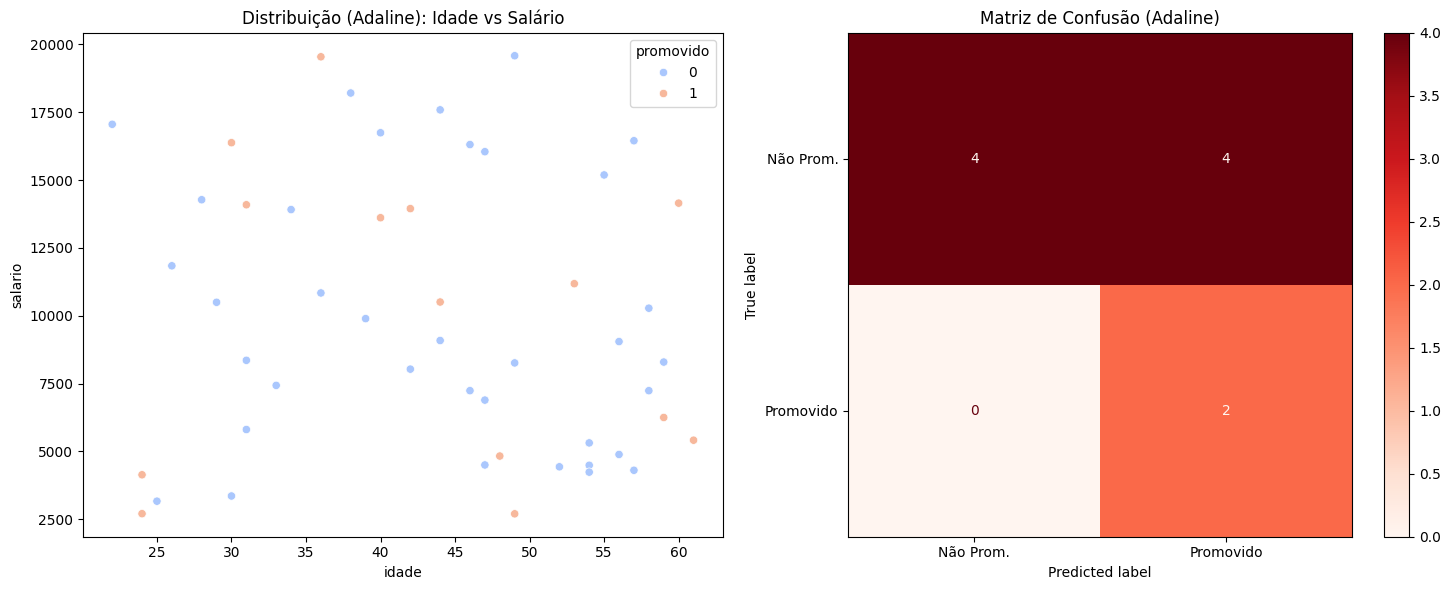

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier # Usado para simular Adaline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# --- (O código de criação do DataFrame permanece o mesmo) ---
np.random.seed(42)
n = 50
nomes = [f"Pessoa_{i:02d}" for i in range(1, n + 1)]
start, end = datetime(1965, 1, 1), datetime(2005, 12, 31)
dias = (end - start).days
datas_nascimento = pd.to_datetime([start + timedelta(days=int(np.random.randint(0, dias))) for _ in range(n)])
hoje = pd.Timestamp.today().normalize()
idade = (hoje.year - datas_nascimento.year).astype(int)
cpf = [str(np.random.randint(10**10, 10**11 - 1)).zfill(11) for _ in range(n)]
cargos = np.random.choice(["Analista Jr", "Analista Pleno", "Analista Sr", "Cientista de Dados", "Eng. de Dados", "Gestor"], size=n)
salario = np.random.randint(2500, 20001, size=n)

df = pd.DataFrame({"Nome": nomes, "data_nascimento": datas_nascimento.date, "idade": idade, "CPF": cpf, "cargo": cargos, "salario": salario})

def classificar_salario(s):
    if s <= 5000: return "C"
    elif 5001 <= s <= 10000: return "B"
    else: return "A"

df["classificacao"] = df["salario"].apply(classificar_salario)
prob_promovido = np.clip(np.where(df["classificacao"] == "C", 0.1, np.where(df["classificacao"] == "B", 0.2, 0.4)), 0, 1)
df["promovido"] = (np.random.rand(n) < prob_promovido).astype(int)

# --- PREPARAÇÃO PARA ADALINE ---

# 1. Transformação de categorias e Normalização
df_ml = pd.get_dummies(df, columns=['cargo', 'classificacao'], drop_first=True)
X = df_ml.drop(columns=['Nome', 'data_nascimento', 'CPF', 'promovido'])
y = df_ml['promovido']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Treinamento da Rede ADALINE (via SGDClassifier)
# loss='squared_error' faz o SGD se comportar como a regra Delta da Adaline
modelo_adaline = SGDClassifier(loss='squared_error', max_iter=1000, tol=1e-3, random_state=42)
modelo_adaline.fit(X_train_scaled, y_train)

# 3. Predição e Avaliação
y_pred = modelo_adaline.predict(X_test_scaled)
acuracia = accuracy_score(y_test, y_pred)

print(f"Acurácia da Adaline: {acuracia:.2%}")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))

# 4. Visualização
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Dispersão
sns.scatterplot(data=df, x='idade', y='salario', hue='promovido', palette='coolwarm', ax=ax[0])
ax[0].set_title('Distribuição (Adaline): Idade vs Salário')

# Gráfico 2: Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Não Prom.', 'Promovido'])
disp.plot(cmap='Reds', ax=ax[1])
ax[1].set_title('Matriz de Confusão (Adaline)')

plt.tight_layout()
plt.show()